# 03 - Data Preprocessing for Classification

**Phase 1, Step 1.3 - Data Preprocessing for Classification**

Extracts bounding boxes from the raw annotations, crops each object into its own image, resizes to 224x224, organizes into 25 class folders, and creates train/val/test splits (70/15/15). This is the dataset the four CNN classifiers will train on.

### 1. Mount Drive and load configuration

In [1]:
!pip install -q datasets pyyaml tqdm scikit-learn matplotlib pandas opencv-python-headless pillow

In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
import os

# ---------------------------------------------------------------------------
# Project configuration - shared across every SmartVision AI notebook.
# All notebooks read/write under this same Google Drive folder so that
# work done in one notebook (e.g. dataset collection) is available to the
# next one (e.g. training), even across separate Colab sessions.
# ---------------------------------------------------------------------------
BASE_DIR = "/content/drive/MyDrive/SmartVisionAI"

RAW_DATA_DIR = os.path.join(BASE_DIR, "raw_data")
RAW_IMAGES_DIR = os.path.join(RAW_DATA_DIR, "images")
RAW_ANNOTATIONS_PATH = os.path.join(RAW_DATA_DIR, "annotations.json")

CLASSIFICATION_DIR = os.path.join(BASE_DIR, "classification")
CLASSIFICATION_TRAIN_DIR = os.path.join(CLASSIFICATION_DIR, "train")
CLASSIFICATION_VAL_DIR = os.path.join(CLASSIFICATION_DIR, "val")
CLASSIFICATION_TEST_DIR = os.path.join(CLASSIFICATION_DIR, "test")

DETECTION_DIR = os.path.join(BASE_DIR, "detection")
DETECTION_IMAGES_DIR = os.path.join(DETECTION_DIR, "images")
DETECTION_LABELS_DIR = os.path.join(DETECTION_DIR, "labels")
DETECTION_YAML_PATH = os.path.join(DETECTION_DIR, "data.yaml")

MODELS_DIR = os.path.join(BASE_DIR, "models")
OUTPUTS_DIR = os.path.join(BASE_DIR, "outputs")

for d in [BASE_DIR, RAW_DATA_DIR, RAW_IMAGES_DIR, CLASSIFICATION_DIR, DETECTION_DIR, MODELS_DIR, OUTPUTS_DIR]:
    os.makedirs(d, exist_ok=True)

# The 25 selected COCO classes (must match COCO category names exactly)
SELECTED_CLASSES = [
    # Vehicles (6)
    "car", "truck", "bus", "motorcycle", "bicycle", "airplane",
    # Person (1)
    "person",
    # Outdoor (3)
    "traffic light", "stop sign", "bench",
    # Animals (6)
    "dog", "cat", "horse", "bird", "cow", "elephant",
    # Kitchen & food (5)
    "bottle", "cup", "bowl", "pizza", "cake",
    # Furniture & indoor (4)
    "chair", "couch", "bed", "potted plant",
]
assert len(SELECTED_CLASSES) == 25

CLASS_TO_IDX = {name: i for i, name in enumerate(SELECTED_CLASSES)}
IDX_TO_CLASS = {i: name for i, name in enumerate(SELECTED_CLASSES)}

def safe_name(class_name):
    return class_name.replace(" ", "_")

IMAGES_PER_CLASS = 350        # -> 8,750 images total (up from 100/class to fight overfitting)
TRAIN_SPLIT = 0.70
VAL_SPLIT = 0.15
TEST_SPLIT = 0.15

CLS_IMG_SIZE = 224            # Classification input resolution (single-resolution throughout)
FINE_TUNE_IMG_SIZE = 384      # Unused by classifier training (reverted to single-resolution); kept for compatibility
YOLO_IMG_SIZE = 640
BATCH_SIZE = 32                # Stage 1 batch size
BATCH_SIZE_STAGE2 = 16         # Smaller batch at 384x384 to fit GPU memory (~2.9x pixels/image)

HF_DATASET_NAME = "detection-datasets/coco"

print("BASE_DIR:", BASE_DIR)
print("Classes:", len(SELECTED_CLASSES))


BASE_DIR: /content/drive/MyDrive/SmartVisionAI
Classes: 25


In [4]:
import json
import random
from PIL import Image

random.seed(42)

with open(RAW_ANNOTATIONS_PATH) as f:
    annotations = json.load(f)
print(f"Loaded {len(annotations)} annotated images.")


Loaded 3087 annotated images.


### 2. Group crops by class (capped at IMAGES_PER_CLASS each)

**Confirmed bbox format:** `detection-datasets/coco` stores `bbox` as `[x_min, y_min, x_max, y_max]` (corner format) - NOT the original COCO `[x, y, width, height]` format. This was verified empirically (100% of boxes are valid under the xyxy interpretation vs. only ~24% under xywh). Every crop below uses the corner-format interpretation accordingly.

In [5]:
crops_by_class = {c: [] for c in SELECTED_CLASSES}

for ann in annotations:
    img_path = os.path.join(RAW_IMAGES_DIR, ann["file"])
    img_w, img_h = ann["width"], ann["height"]
    for box in ann["boxes"]:
        cname = box["class"]
        if len(crops_by_class[cname]) >= IMAGES_PER_CLASS:
            continue
        x1, y1, x2, y2 = box["bbox"]  # x_min, y_min, x_max, y_max
        # Defensive clamp in case of minor annotation overshoot at image edges
        x1 = max(0, min(x1, img_w))
        y1 = max(0, min(y1, img_h))
        x2 = max(0, min(x2, img_w))
        y2 = max(0, min(y2, img_h))
        if x2 <= x1 or y2 <= y1:
            continue  # degenerate box, skip
        crops_by_class[cname].append({"img_path": img_path, "bbox": (x1, y1, x2, y2)})

for c, items in crops_by_class.items():
    print(f"{c:<15} {len(items)} crops")


car             350 crops
truck           350 crops
bus             350 crops
motorcycle      350 crops
bicycle         350 crops
airplane        350 crops
person          350 crops
traffic light   350 crops
stop sign       350 crops
bench           350 crops
dog             350 crops
cat             350 crops
horse           350 crops
bird            350 crops
cow             350 crops
elephant        350 crops
bottle          350 crops
cup             350 crops
bowl            350 crops
pizza           349 crops
cake            347 crops
chair           350 crops
couch           350 crops
bed             344 crops
potted plant    348 crops


### 3. Crop, resize, split 70/15/15, and save into class folders

In [6]:
import shutil as _shutil
# Clear any stale crops from a previous run before rebuilding, so leftover
# images from an earlier (possibly differently-labeled) run never mix in.
_shutil.rmtree(CLASSIFICATION_DIR, ignore_errors=True)

for split_dir in (CLASSIFICATION_TRAIN_DIR, CLASSIFICATION_VAL_DIR, CLASSIFICATION_TEST_DIR):
    for cname in SELECTED_CLASSES:
        os.makedirs(os.path.join(split_dir, safe_name(cname)), exist_ok=True)

split_dirs = {"train": CLASSIFICATION_TRAIN_DIR, "val": CLASSIFICATION_VAL_DIR, "test": CLASSIFICATION_TEST_DIR}

for cname, items in crops_by_class.items():
    random.shuffle(items)
    n = len(items)
    n_train = int(n * TRAIN_SPLIT)
    n_val = int(n * VAL_SPLIT)
    splits = {
        "train": items[:n_train],
        "val": items[n_train:n_train + n_val],
        "test": items[n_train + n_val:],
    }
    for split_name, split_items in splits.items():
        out_dir = os.path.join(split_dirs[split_name], safe_name(cname))
        for i, item in enumerate(split_items):
            x1, y1, x2, y2 = item["bbox"]  # x_min, y_min, x_max, y_max
            img = Image.open(item["img_path"]).convert("RGB")
            crop = img.crop((x1, y1, x2, y2)).resize((CLS_IMG_SIZE, CLS_IMG_SIZE))
            crop.save(os.path.join(out_dir, f"{safe_name(cname)}_{split_name}_{i:04d}.jpg"))
    print(f"{cname:<15} train={len(splits['train']):3d}  val={len(splits['val']):3d}  test={len(splits['test']):3d}")


car             train=244  val= 52  test= 54
truck           train=244  val= 52  test= 54
bus             train=244  val= 52  test= 54
motorcycle      train=244  val= 52  test= 54
bicycle         train=244  val= 52  test= 54
airplane        train=244  val= 52  test= 54
person          train=244  val= 52  test= 54
traffic light   train=244  val= 52  test= 54
stop sign       train=244  val= 52  test= 54
bench           train=244  val= 52  test= 54
dog             train=244  val= 52  test= 54
cat             train=244  val= 52  test= 54
horse           train=244  val= 52  test= 54
bird            train=244  val= 52  test= 54
cow             train=244  val= 52  test= 54
elephant        train=244  val= 52  test= 54
bottle          train=244  val= 52  test= 54
cup             train=244  val= 52  test= 54
bowl            train=244  val= 52  test= 54
pizza           train=244  val= 52  test= 53
cake            train=242  val= 52  test= 53
chair           train=244  val= 52  test= 54
couch     

### 4. Sanity check: view a few processed crops

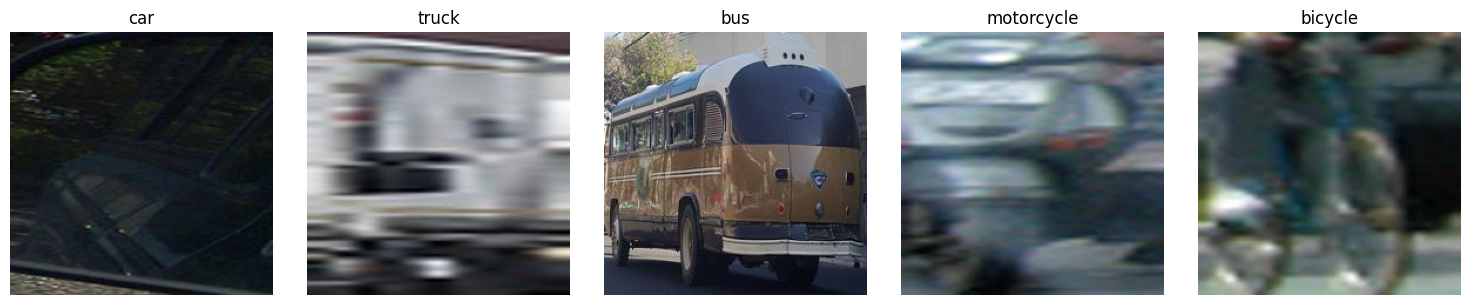

In [7]:
import matplotlib.pyplot as plt
import glob

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for ax, cname in zip(axes, SELECTED_CLASSES[:5]):
    files = glob.glob(os.path.join(CLASSIFICATION_TRAIN_DIR, safe_name(cname), "*.jpg"))
    if files:
        ax.imshow(Image.open(files[0]))
    ax.set_title(cname)
    ax.axis("off")
plt.tight_layout()
plt.show()


**Next notebook:** `04_Data_Augmentation.ipynb` visualizes the augmentation pipeline that each training notebook applies on top of this data.